In [ ]:
%reload_ext autoreload
%autoreload 2
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from collections import OrderedDict
from qiskit_metal.qlibrary.core import QComponent

from qiskit_metal.qlibrary.sample_shapes.rectangle import Rectangle
from qiskit_metal.qlibrary.sample_shapes.rectangle_hollow import RectangleHollow
from src.qiskit_metal.qlibrary.user_components.self_define import Cross
from src.qiskit_metal.qlibrary.user_components.fillet_q import Fillet_Qubit
from src.qiskit_metal.qlibrary.user_components.round_tee import Round_Tee
from src.qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from src.qiskit_metal.qlibrary.sample_shapes.right_triangle import RightTriangle

from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround

from qiskit_metal.qlibrary.couplers.line_tee import LineTee
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.launchpad_wb_coupled import LaunchpadWirebondCoupled
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven

from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.toolbox_metal.parsing import parse_value

from qiskit_metal.analyses.quantization import EPRanalysis
import pyEPR as epr
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
from qiskit_metal.analyses.sweep_and_optimize.sweeping import Sweeping
from qiskit_metal.qlibrary.core import QComponent

import numpy as np 
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'qiskit_metal.qlibrary.sample_shapes.right_triangle'

In [2]:
# 定義所有版本的完整參數
# 每個 Key (如 '3-1') 裡面都要包含「所有」需要的變數
configs = {
    "2": {
        "draw_L1": True,
        "draw_L2": True,
        "draw_L3": True,
        "draw_L4": True,
        "draw_R1": True,
        "draw_R2": True,
        "draw_R3": True,
        "draw_R4": True,
        "reso_freq": 5,
        "draw_TL_anchors": True,
        "draw_pocket_1": True,
        "draw_pocket_2": True,
        "draw_qubit_1": True,
        "draw_qubit_2": True,
        "draw_reso_1": True,
        "draw_reso_2": True,
        "draw_fl_1": True,
        "draw_fl_2": True,
        "draw_cl_1": True,
        "draw_cl_2": True,
        "draw_folded_TL": True,
        "draw_coupling_pad_1": True,
        "draw_coupling_pad_2": True,
        "draw_couple_line_1": True,
        "draw_couple_line_2": True,
    },
    "3-1": {
        "draw_L1": True,
        "draw_L2": True,
        "draw_L3": True,
        "draw_L4": True,
        "draw_R1": True,
        "draw_R2": True,
        "draw_R3": True,
        "draw_R4": True,
        "reso_freq": 7,
        "draw_TL_anchors": True,
        "draw_pocket_1": True,
        "draw_pocket_2": True,
        "draw_qubit_1": False,
        "draw_qubit_2": False,
        "draw_reso_1": True,
        "draw_reso_2": True,
        "draw_fl_1": True,
        "draw_fl_2": True,
        "draw_cl_1": True,
        "draw_cl_2": True,
        "draw_folded_TL": True,
        "draw_coupling_pad_1": True,
        "draw_coupling_pad_2": True,
        "draw_couple_line_1": True,
        "draw_couple_line_2": True,
    },
    "3-2": {
        "draw_L1": True,
        "draw_L2": True,
        "draw_L3": True,
        "draw_L4": True,
        "draw_R1": True,
        "draw_R2": True,
        "draw_R3": True,
        "draw_R4": True,
        "reso_freq": 5,
        "draw_TL_anchors": True,
        "draw_pocket_1": True,
        "draw_pocket_2": True,
        "draw_qubit_1": False,
        "draw_qubit_2": False,
        "draw_reso_1": True,
        "draw_reso_2": True,
        "draw_fl_1": True,
        "draw_fl_2": True,
        "draw_cl_1": True,
        "draw_cl_2": True,
        "draw_folded_TL": True,
        "draw_coupling_pad_1": True,
        "draw_coupling_pad_2": True,
        "draw_couple_line_1": True,
        "draw_couple_line_2": True,
    },
    "4-1": {
        "draw_L1": True,
        "draw_L2": True,
        "draw_L3": True,
        "draw_L4": True,
        "draw_R1": True,
        "draw_R2": False,
        "draw_R3": False,
        "draw_R4": True,
        "reso_freq": 5,
        "draw_TL_anchors": True,
        "draw_pocket_1": True,
        "draw_pocket_2": False,
        "draw_qubit_1": False,
        "draw_qubit_2": False,
        "draw_reso_1": True,
        "draw_reso_2": False,
        "draw_fl_1": True,
        "draw_fl_2": False,
        "draw_cl_1": True,
        "draw_cl_2": False,
        "draw_folded_TL": True,
        "draw_coupling_pad_1": True,
        "draw_coupling_pad_2": False,
        "draw_couple_line_1": True,
        "draw_couple_line_2": False,
    },
    "4-2": {
        "draw_L1": True,
        "draw_L2": True,
        "draw_L3": True,
        "draw_L4": True,
        "draw_R1": True,
        "draw_R2": False,
        "draw_R3": False,
        "draw_R4": True,
        "reso_freq": 7,
        "draw_TL_anchors": True,
        "draw_pocket_1": True,
        "draw_pocket_2": False,
        "draw_qubit_1": False,
        "draw_qubit_2": False,
        "draw_reso_1": True,
        "draw_reso_2": False,
        "draw_fl_1": True,
        "draw_fl_2": False,
        "draw_cl_1": True,
        "draw_cl_2": False,
        "draw_folded_TL": True,
        "draw_coupling_pad_1": True,
        "draw_coupling_pad_2": False,
        "draw_couple_line_1": True,
        "draw_couple_line_2": False,
    }
}    
 

In [3]:
target_version = "4-2" 
data = configs[target_version]

# 左邊(L)與右邊(R)結構
draw_L1 = data["draw_L1"]
draw_L2 = data["draw_L2"]
draw_L3 = data["draw_L3"]
draw_L4 = data["draw_L4"]

draw_R1 = data["draw_R1"]
draw_R2 = data["draw_R2"]
draw_R3 = data["draw_R3"]
draw_R4 = data["draw_R4"]

# 核心參數
reso_freq = data["reso_freq"]
draw_TL_anchors = data["draw_TL_anchors"]

# Pocket 與 Qubit
draw_pocket_1 = data["draw_pocket_1"]
draw_pocket_2 = data["draw_pocket_2"]
draw_qubit_1 = data["draw_qubit_1"]
draw_qubit_2 = data["draw_qubit_2"]

# Resonator (Reso)
draw_reso_1 = data["draw_reso_1"]
draw_reso_2 = data["draw_reso_2"]

# Flux Line (fl)
draw_fl_1 = data["draw_fl_1"]
draw_fl_2 = data["draw_fl_2"]

# Charge Line (cl)
draw_cl_1 = data["draw_cl_1"]
draw_cl_2 = data["draw_cl_2"]

# Transmission Line (TL)
draw_folded_TL = data["draw_folded_TL"]

# Coupling Pad
draw_coupling_pad_1 = data["draw_coupling_pad_1"]
draw_coupling_pad_2 = data["draw_coupling_pad_2"]

# Coupling Line
draw_couple_line_1 = data["draw_couple_line_1"]
draw_couple_line_2 = data["draw_couple_line_2"]

# 最後自動產生檔名
save_file_name = f'Fluxonium_readout_cl_fl_filtter_{target_version}.gds'


if reso_freq ==7:
    TL_mid_y2 = 1.0
if reso_freq == 5:
    TL_mid_y2 = 2.0
draw_TL_straight = False


qubit_1_posx = 0.05
qubit_1_posy = -2
qubit_2_posx = 1.350
qubit_2_posy = -2


cpw_width = 0.01
cpw_gap = 0.006

In [4]:
class VirtualJunction(QComponent):
    """
    A component with no geometry, only pins.
    Used to create a T-junction for routing.
    """
    # 定義元件的預設參數
    default_options = dict(
        pin_width=cpw_width # 讓 pin 的寬度可以被設定
    )

    def make(self):
        """
        This is the method that Qiskit Metal calls to draw the component.
        We will only add pins here and no geometry.
        """
        p = self.p  # 取得解析後的參數 (parsed options)

        # 取得元件的中心位置
        pos_x = p.pos_x
        pos_y = p.pos_y

        # 定義三個 pin，它們的向量都從中心點向外指
        # pin 的格式是 [起點, 終點]
        pin_len = 1e-6 # 一個極小值，只用來定義方向
        
        # pin 的法向量 (normal vector) 會從第一個點指向第二個點
        # Route* 元件會從 pin 的終點開始連接
        pin_left = [[pos_x, pos_y+p.pin_width/2], [pos_x - pin_len, pos_y+p.pin_width/2]]
        pin_right = [[pos_x, pos_y-p.pin_width/2], [pos_x + pin_len, pos_y-p.pin_width/2]]
        pin_bottom = [[pos_x-p.pin_width/2, pos_y], [pos_x-p.pin_width/2, pos_y - pin_len]]
        pin_top = [[pos_x+p.pin_width/2, pos_y], [pos_x+p.pin_width/2, pos_y + pin_len]]

        # 將 pins 加入到元件中
        self.add_pin('left', points=pin_left, width=p.pin_width)
        self.add_pin('right', points=pin_right, width=p.pin_width)
        self.add_pin('bottom', points=pin_bottom, width=p.pin_width)
        self.add_pin('top', points=pin_top, width=p.pin_width)


In [5]:
class VirtualJunction(QComponent):
    """
    A component with no geometry, only pins.
    Used to create a T-junction for routing.
    """
    # 定義元件的預設參數
    default_options = dict(
        pin_width=cpw_width # 讓 pin 的寬度可以被設定
    )

    def make(self):
        """
        This is the method that Qiskit Metal calls to draw the component.
        We will only add pins here and no geometry.
        """
        p = self.p  # 取得解析後的參數 (parsed options)

        # 取得元件的中心位置
        pos_x = p.pos_x
        pos_y = p.pos_y

        # 定義三個 pin，它們的向量都從中心點向外指
        # pin 的格式是 [起點, 終點]
        pin_len = 1e-6 # 一個極小值，只用來定義方向
        
        # pin 的法向量 (normal vector) 會從第一個點指向第二個點
        # Route* 元件會從 pin 的終點開始連接
        pin_left = [[pos_x, pos_y], [pos_x - pin_len, pos_y]]
        pin_right = [[pos_x, pos_y], [pos_x + pin_len, pos_y]]
        pin_bottom = [[pos_x, pos_y], [pos_x, pos_y - pin_len]]
        pin_top = [[pos_x, pos_y], [pos_x, pos_y + pin_len]]

        # 將 pins 加入到元件中
        self.add_pin('left', points=pin_left, width=p.pin_width, input_as_norm=True)
        self.add_pin('right', points=pin_right, width=p.pin_width, input_as_norm=True)
        self.add_pin('bottom', points=pin_bottom, width=p.pin_width, input_as_norm=True)
        self.add_pin('top', points=pin_top, width=p.pin_width, input_as_norm=True)


# Circuit Design

In [6]:
design = designs.DesignPlanar()
gui = MetalGUI(design)
design.overwrite_enabled = True
design.chips.main.size.size_x = '10 mm'
design.chips.main.size.size_y = '10 mm'
design.chips.main.size.size_z = '-650 um'
design.chips.main.material = 'sapphire'
var = design.variables
print(var)

{'cpw_width': '10 um', 'cpw_gap': '6 um'}


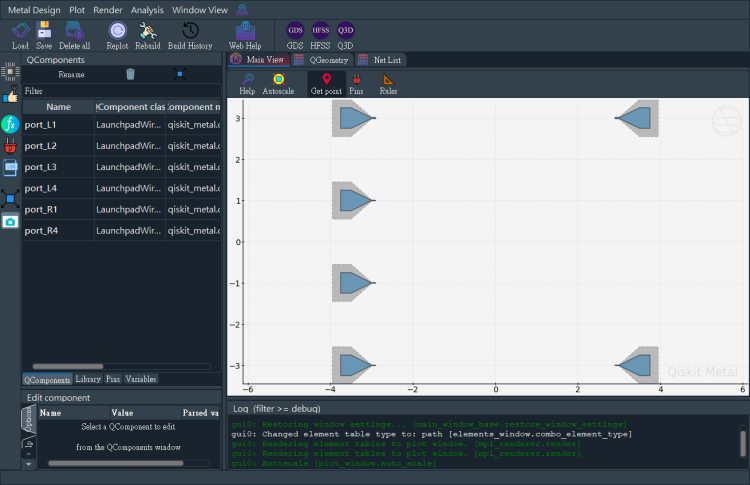

In [7]:
"""
Set 8 ports. 2 for readout TL, 3 for charge line and 3 for flux line. 
"""

# 可控制要畫哪些 port
# True 表示要畫，False 表示不畫


x_port, y_port = 3.000, 3.000
TL_width, TL_gap = 0.020, 0.012

if draw_L1:
    port_L1 = LaunchpadWirebond(design, 'port_L1', options = dict(pos_x = -x_port, pos_y =  y_port, orientation = '  0', 
                                                              pad_width = 0.5, pad_height = 0.25, pad_gap = 0.2, taper_height = 0.5,
                                                              lead_length = 0.100, trace_width=0.020, trace_gap=0.012))
if draw_L2:
    port_L2 = LaunchpadWirebond(design, 'port_L2', options = dict(pos_x = -x_port, pos_y =  1.0, orientation = '  0', 
                                                              pad_width = 0.5, pad_height = 0.25, pad_gap = 0.2, taper_height = 0.5,
                                                              lead_length = 0.100, trace_width=cpw_width, trace_gap=cpw_gap))
if draw_L3:
    port_L3 = LaunchpadWirebond(design, 'port_L3', options = dict(pos_x = -x_port, pos_y = -1.0, orientation = '  0', 
                                                              pad_width = 0.5, pad_height = 0.25, pad_gap = 0.2, taper_height = 0.5,
                                                              lead_length = 0.100, trace_width=cpw_width, trace_gap=cpw_gap))
if draw_L4:
    port_L4 = LaunchpadWirebond(design, 'port_L4', options = dict(pos_x = -x_port, pos_y = -y_port, orientation = '  0', 
                                                              pad_width = 0.5, pad_height = 0.25, pad_gap = 0.2, taper_height = 0.5,
                                                              lead_length = 0.100, trace_width=cpw_width, trace_gap=cpw_gap))
if draw_R1:
    port_R1 = LaunchpadWirebond(design, 'port_R1', options = dict(pos_x =  x_port, pos_y =  y_port, orientation = '180', 
                                                              pad_width = 0.5, pad_height = 0.25, pad_gap = 0.2, taper_height = 0.5,
                                                              lead_length = 0.100, trace_width=0.020, trace_gap=0.012))
if draw_R2:
    port_R2 = LaunchpadWirebond(design, 'port_R2', options = dict(pos_x =  x_port, pos_y =  1.0, orientation = '180', 
                                                              pad_width = 0.5, pad_height = 0.25, pad_gap = 0.2, taper_height = 0.5,
                                                              lead_length = 0.100, trace_width=cpw_width, trace_gap=cpw_gap))
if draw_R3:
    port_R3 = LaunchpadWirebond(design, 'port_R3', options = dict(pos_x =  x_port, pos_y = -1.0, orientation = '180', 
                                                              pad_width = 0.5, pad_height = 0.25, pad_gap = 0.2, taper_height = 0.5,
                                                              lead_length = 0.100, trace_width=cpw_width, trace_gap=cpw_gap))
if draw_R4:
    port_R4 = LaunchpadWirebond(design, 'port_R4', options = dict(pos_x =  x_port, pos_y = -y_port, orientation = '180', 
                                                              pad_width = 0.5, pad_height = 0.25, pad_gap = 0.2, taper_height = 0.5,
                                                              lead_length = 0.100, trace_width=cpw_width, trace_gap=cpw_gap))

gui.rebuild()
gui.autoscale()
gui.screenshot()

In [8]:
"""
Set transmission line (TL).
"""
# 可控制是否畫 TL

TL_width, TL_gap = 0.020, 0.012

if draw_TL_anchors:
    port1y = port_R1.options.pos_y
    mid_x1 = -2.0
    mid_y1 = port1y
    mid_x2 = mid_x1
    mid_y2 = TL_mid_y2
    mid_x3 = 2.0
    mid_y3 = mid_y2
    mid_x4 = mid_x3
    mid_y4 = mid_y1
    res_start_y = mid_y2

    anchors = {
        "0": (mid_x1, mid_y1),
        "1": (mid_x2, mid_y2),
        "2": (mid_x3, mid_y3),
        "3": (mid_x4, mid_y4),
    }

    bottom_TL = RouteAnchors(
        design, 'bottom_TL',
        dict(
            pin_inputs = dict(
                start_pin = dict(component = 'port_L1', pin = 'tie'),
                end_pin = dict(component = 'port_R1', pin = 'tie')
            ),
            anchors = anchors,
            trace_width = TL_width,
            trace_gap = TL_gap,
            fillet = 0.100,  # 摺疊處為平角
            hfss_wire_bonds = True,
            lead = dict(start_straight=0.500, end_straight=0.500)
        )
    )

if draw_TL_straight:
    port1y = port_R1.options.pos_y
    TL_width, TL_gap = 0.020, 0.012
    res_start_y = port_L1.options.pos_y
    TL = RouteStraight(design, 'TL', 
        dict(pin_inputs = dict(start_pin = dict(component = 'port_L1', pin = 'tie'), 
                                 end_pin = dict(component = 'port_R1', pin = 'tie')),
             trace_width = TL_width, trace_gap = TL_gap, fillet = 0.10, hfss_wire_bonds = True,
             lead = dict(start_straight=0.500, end_straight=0.500)))
    gui.rebuild()
    gui.autoscale()
    gui.screenshot()

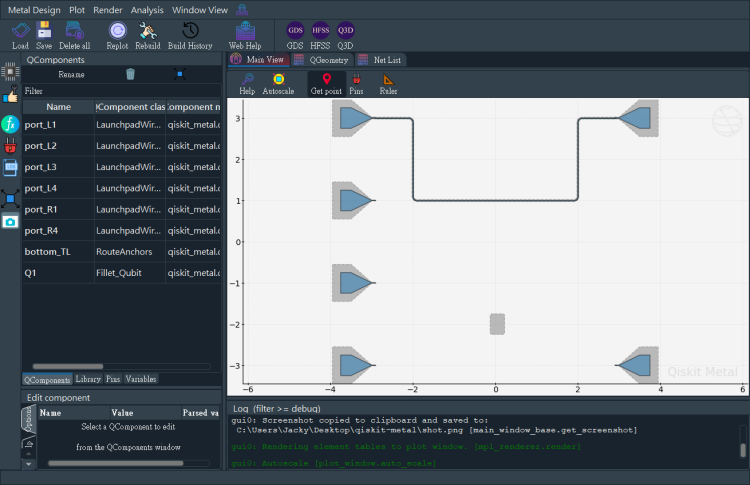

In [9]:
"""
Set 3 separated fluxonia with rectangles. Make sure the layers of fluxonium components are correct for fabrication process. 
"""
x_center, y_center = 0.000, 0.000
x_dis, y_dis = 1.350, 0.000

q_opt1 = {'pos_x': qubit_1_posx, 'pos_y': qubit_1_posy, 'orientation': 0, 
         'pad_gap': 0.030, 'arm_width': 0.008, 'arm_length': 0.090, 'arm_fillet': 0.020,
         'pad_width': 0.200, 'pad_height': 0.050, 'pad_fillet': 0.050, 
         'pocket_width': 0.350, 'pocket_height': 0.500, 'pocket_fillet': 0.050, 
         'layer': 1, 'draw_qubit': draw_qubit_1}

q_opt2 = {'pos_x': qubit_2_posx, 'pos_y': qubit_2_posy, 'orientation': 0, 
         'pad_gap': 0.030, 'arm_width': 0.008, 'arm_length': 0.090, 'arm_fillet': 0.020,
         'pad_width': 0.200, 'pad_height': 0.050, 'pad_fillet': 0.050, 
         'pocket_width': 0.350, 'pocket_height': 0.500, 'pocket_fillet': 0.050, 
         'layer': 1, 'draw_qubit': draw_qubit_2}
if draw_pocket_1:
    Q1 = Fillet_Qubit(design, 'Q1', q_opt1)
if draw_pocket_2:
    Q3 = Fillet_Qubit(design, 'Q3', q_opt2)

gui.rebuild()
gui.autoscale()
gui.screenshot()

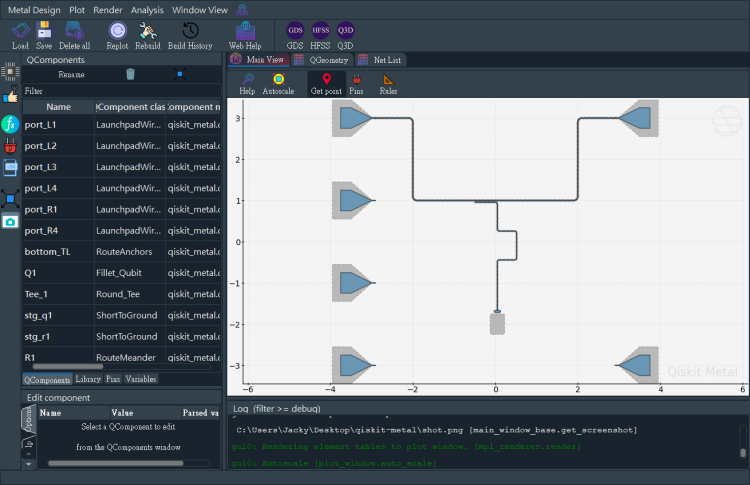

In [10]:
"""
Set resonators.
"""
# 新增選擇變數
# 設定 draw_1 或 draw_2 來選擇要畫哪一個
# 例如 draw_1=True, draw_2=False 只畫1；draw_1=False, draw_2=True 只畫2
# 兩個都 False 則都不畫

if draw_reso_1:
    res_width, res_gap = 0.015, 0.009
    if reso_freq == 7:
        R1_len = 4.000 # ~ 4.2, 4.3, 4.4 #fr=7.67284
        l_couple, grd_gap = 0.500, 0.004
    if reso_freq == 5:
        R1_len = 5.300 #fr=6.02265
        l_couple, grd_gap = 0.700 , 0.004
    spacing, fillet = 0.700, 0.050 # fillet > 1.5*(res_width+res_gap*2)
    R_ext, shift_x, shift_y = 0.200, 0, 0.309
    tee_width, tee_length, tee_fillet = 0.050, 0.100, 0.005

    Tee_1 = Round_Tee(design, "Tee_1",
        dict(ref_qc = Q1, rel_ori = "90", shift_x = shift_x, shift_y = shift_y,
             cpw_width = res_width, cpw_gap = res_gap, ext_len = R_ext, 
             tee_width = tee_width, tee_length = tee_length, tee_fillet = tee_fillet)
    )

    stg_q1 = ShortToGround(design, 'stg_q1',
        {'pos_x': Q1.options.pos_x, 'pos_y': qubit_1_posy + Tee_1.options.shift_y + Tee_1.options.tee_width/2 + Tee_1.options.ext_len, 'orientation': '270'})
    stg_r1 = ShortToGround(design, 'stg_r1',
        {'pos_x': Q1.options.pos_x-(l_couple+fillet), 'pos_y': res_start_y-TL_gap-res_gap-(TL_width+res_width)/2-grd_gap, 'orientation': '180'})
    start_jog = OrderedDict()
    start_jog[0] = ["R", 0.7]
    R1 = RouteMeander(design, 'R1', 
        options = dict(total_length = R1_len-R_ext, fillet=fillet, hfss_wire_bonds = True, 
                       lead = dict(start_straight=l_couple+fillet, end_straight=0.3,
                                   start_jogged_extension = start_jog), 
                       trace_width = res_width, trace_gap = res_gap,
                       meander = dict(
                           spacing=spacing, 
                           asymmetry=0
                       ),
                       pin_inputs = Dict(start_pin = Dict(component = 'stg_r1', pin = 'short'),
                                           end_pin = Dict(component = 'stg_q1', pin = 'short'))))

if draw_reso_2:
    if reso_freq == 7:
        R3_len = 4.100 # ~ 4.2, 4.3, 4.4 #fr=7.48581
        l_couple, grd_gap = 0.505, 0.004
    if reso_freq == 5:
        R3_len = 5.455 # fr = 5.85143
        l_couple, grd_gap = 0.730, 0.004
    spacing, fillet = 0.700, 0.050 # fillet > 1.5*(res_width+res_gap*2)
    R_ext, shift_x, shift_y = 0.200, 0, 0.309
    tee_width, tee_length, tee_fillet = 0.050, 0.100, 0.005

    Tee_3 = Round_Tee(design, "Tee_3",
        dict(ref_qc = Q3, rel_ori = "90", shift_x = shift_x, shift_y = shift_y,
             cpw_width = res_width, cpw_gap = res_gap, ext_len = R_ext, 
             tee_width = tee_width, tee_length = tee_length, tee_fillet = tee_fillet)
    )

    stg_q3 = ShortToGround(design, 'stg_q3',
        {'pos_x': Q3.options.pos_x, 'pos_y': qubit_2_posy + Tee_3.options.shift_y + Tee_3.options.tee_width/2 + Tee_3.options.ext_len, 'orientation': '270'})
    stg_r3 = ShortToGround(design, 'stg_r3',
        {'pos_x': Q3.options.pos_x-(l_couple+fillet), 'pos_y': res_start_y-TL_gap-res_gap-(TL_width+res_width)/2-grd_gap, 'orientation': '180'})
    start_jog = OrderedDict()
    start_jog[0] = ["R", 0.7]
    R3 = RouteMeander(design, 'R3', 
        options = dict(total_length = R3_len-R_ext, fillet=fillet, hfss_wire_bonds = True, 
                       lead = dict(start_straight=l_couple+fillet, end_straight=0.3,
                                   start_jogged_extension = start_jog), 
                       trace_width = res_width, trace_gap = res_gap,
                       meander = dict(
                           spacing=spacing, 
                           asymmetry=0
                       ),
                       pin_inputs = Dict(start_pin = Dict(component = 'stg_r3', pin = 'short'),
                                           end_pin = Dict(component = 'stg_q3', pin = 'short'))))

gui.rebuild()
gui.autoscale()
gui.screenshot()

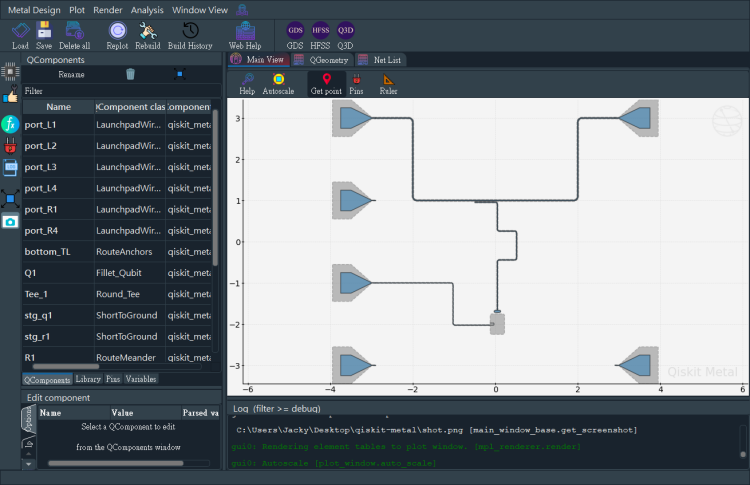

In [11]:
"""
Flux bias line for each qubit. 
"""
# 新增選擇變數
# 設定 draw_1 或 draw_2 來選擇要畫哪一個
# 例如 draw_1=True, draw_2=False 只畫Q1；draw_1=False, draw_2=True 只畫Q3
# 兩個都 True 則都畫

if draw_fl_1:
    q_loop_width, q_loop_height, q_loop_trace = 0.060, 0.010, 0.002
    loop_H, loop_W, loop_wid = 0.050, 0.090, 0.005
    fl_loop_stg_1A = ShortToGround(design, 'fl_loop_stg_1A', 
        dict(pos_x=Q1.options.pos_x-Q1.options.pocket_width/2, pos_y=Q1.options.pos_y-loop_H/2, orientation=180))
    fl_loop_stg_1B = ShortToGround(design, 'fl_loop_stg_1B', 
        dict(pos_x=Q1.options.pos_x-Q1.options.pocket_width/2, pos_y=Q1.options.pos_y+loop_H/2, orientation=180))
    fl_loop_route_1 = RouteStraight(design, 'fl_loop_route_1',
        dict(trace_width=loop_wid, trace_gap=0, fillet=0.010, hfss_wire_bonds=False,
             lead = dict(start_straight=loop_W, end_straight=loop_W),
             pin_inputs = Dict(start_pin = Dict(component = 'fl_loop_stg_1A', pin = 'short'),
                                 end_pin = Dict(component = 'fl_loop_stg_1B', pin = 'short'))))
    fl_q_stg_1 = ShortToGround(design, 'fl_q_stg_1', 
        dict(pos_x=Q1.options.pos_x-Q1.options.pocket_width/2, pos_y=Q1.options.pos_y-loop_H/2, orientation=0))
    fl_q_route_1 = RoutePathfinder(design, 'fl_q_route_1', 
        dict(trace_width=cpw_width, trace_gap=cpw_gap, fillet=0.050, hfss_wire_bonds=True,
             lead = dict(start_straight=0.300, end_straight=0.900),
             pin_inputs = Dict(start_pin = Dict(component = 'port_L3', pin = 'tie'),
                                 end_pin = Dict(component = 'fl_q_stg_1', pin = 'short'))))

if draw_fl_2:
    q_loop_width, q_loop_height, q_loop_trace = 0.060, 0.010, 0.002
    loop_H, loop_W, loop_wid = 0.050, 0.090, 0.005
    fl_loop_stg_3A = ShortToGround(design, 'fl_loop_stg_3A', 
        dict(pos_x=Q3.options.pos_x+Q3.options.pocket_width/2, pos_y=Q3.options.pos_y-loop_H/2, orientation=  0))
    fl_loop_stg_3B = ShortToGround(design, 'fl_loop_stg_3B', 
        dict(pos_x=Q3.options.pos_x+Q3.options.pocket_width/2, pos_y=Q3.options.pos_y+loop_H/2, orientation=  0))
    fl_loop_route_3 = RouteStraight(design, 'fl_loop_route_3',
        dict(trace_width=loop_wid, trace_gap=0, fillet=0.010, hfss_wire_bonds=False,
             lead = dict(start_straight=loop_W, end_straight=loop_W),
             pin_inputs = Dict(start_pin = Dict(component = 'fl_loop_stg_3A', pin = 'short'),
                                 end_pin = Dict(component = 'fl_loop_stg_3B', pin = 'short'))))
    fl_q_stg_3 = ShortToGround(design, 'fl_q_stg_3', 
        dict(pos_x=Q3.options.pos_x+Q3.options.pocket_width/2, pos_y=Q3.options.pos_y-loop_H/2, orientation=180))
    fl_q_route_3 = RoutePathfinder(design, 'fl_q_route_3', 
        dict(trace_width=cpw_width, trace_gap=cpw_gap, fillet=0.050, hfss_wire_bonds=True,
             lead = dict(start_straight=0.300, end_straight=0.900),
             pin_inputs = Dict(start_pin = Dict(component = 'port_R3', pin = 'tie'),
                                 end_pin = Dict(component = 'fl_q_stg_3', pin = 'short'))))


gui.rebuild()
gui.autoscale()
gui.screenshot()

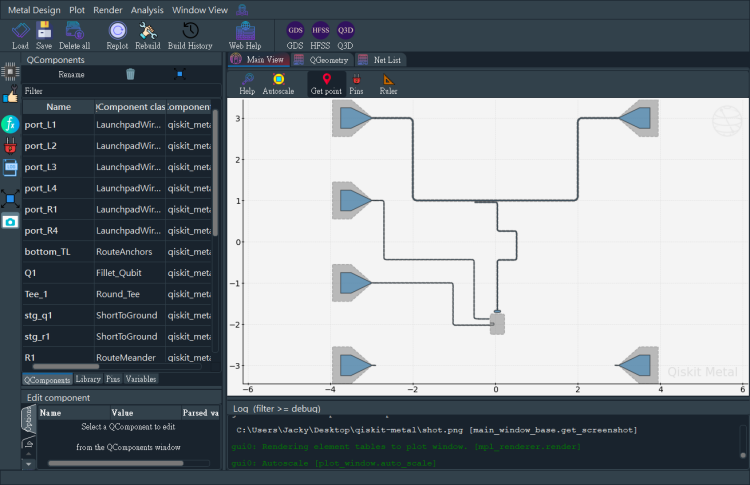

In [12]:
"""
Charge line for each qubit. 
"""

cpw_width, cpw_gap = parse_value(var.cpw_width, var), parse_value(var.cpw_gap, var)

if draw_cl_1:
    cl_vac, cl_grd, cl_ext = 0.020, 0.010, 0.300
    cl_shifty = 0.13
    cl_q1_gap_1 = Rectangle(design, 'cl_q1_gap_1', 
        dict(pos_x = Q1.options.pos_x-Q1.options.pocket_width/2-cl_grd-cl_ext/2, pos_y = Q1.options.pos_y+cl_shifty, 
            width = cl_ext, height = cpw_gap*2+cpw_width, subtract=True))
    cl_q1_trace_1 = Rectangle(design, 'cl_q1_trace_1', 
        dict(pos_x = Q1.options.pos_x-Q1.options.pocket_width/2-cl_grd-cl_ext/2, pos_y = Q1.options.pos_y+cl_shifty, 
            width = cl_ext-cl_vac*2, height = cpw_width))
    cl_q_stg_1 = ShortToGround(design, 'cl_q_stg_1', 
        dict(pos_x = Q1.options.pos_x-Q1.options.pocket_width/2-cl_grd-cl_ext+cl_vac, pos_y = Q1.options.pos_y+cl_shifty, 
            orientation=0))


    cl_q_route_1 = RoutePathfinder(design, 'cl_q_route_1', 
        dict(trace_width=cpw_width, trace_gap=cpw_gap, fillet=0.050, hfss_wire_bonds=True,
            lead = dict(start_straight=0.200, end_straight=0.100),
            pin_inputs = Dict(start_pin = Dict(component = 'port_L2', pin = 'tie'),
                                end_pin = Dict(component = 'cl_q_stg_1', pin = 'short'))))

if draw_cl_2:
    cl_q1_gap_3 = Rectangle(design, 'cl_q1_gap_3', 
        dict(pos_x = Q3.options.pos_x+Q3.options.pocket_width/2+cl_grd+cl_ext/2, pos_y = Q3.options.pos_y+cl_shifty, 
            width = cl_ext, height = cpw_gap*2+cpw_width, subtract=True))

    cl_q1_trace_3 = Rectangle(design, 'cl_q1_trace_3', 
        dict(pos_x = Q3.options.pos_x+Q3.options.pocket_width/2+cl_grd+cl_ext/2, pos_y = Q3.options.pos_y+cl_shifty, 
            width = cl_ext-cl_vac*2, height = cpw_width))

    cl_q_stg_3 = ShortToGround(design, 'cl_q_stg_3', 
        dict(pos_x = Q3.options.pos_x+Q3.options.pocket_width/2+cl_grd+cl_ext-cl_vac, pos_y = Q3.options.pos_y+cl_shifty, 
            orientation=180))

    cl_q_route_3 = RoutePathfinder(design, 'cl_q_route_3', 
        dict(trace_width=cpw_width, trace_gap=cpw_gap, fillet=0.050, hfss_wire_bonds=True,
            lead = dict(start_straight=0.200, end_straight=0.100),
            pin_inputs = Dict(start_pin = Dict(component = 'port_R2', pin = 'tie'),
                                end_pin = Dict(component = 'cl_q_stg_3', pin = 'short'))))

gui.rebuild()
gui.autoscale()
gui.screenshot()

In [13]:
def find_bc_solutions(L, delta, max_n=100):
    """
    在 n = 1,2,...,max_n 範圍內搜尋 (b, c) 解。
    條件：
      n = (L - delta) / (2c) 為正整數
      floor((L-b)/(2*(b+c))) == n  == (L-delta)/(2c)
    回傳值：一個 list，每項為 (n, c, b_min, b_max)，
      其中 b_min < b <= b_max。
    """
    solutions = []
    for n in range(1, max_n+1):
        # 計算 c
        c = (L - delta) / (2 * n)
        if c <= 0:
            continue
        
        # 計算 b 的不等式邊界
        b_min = ((n+1)*delta - L) / (n*(2*n+3))  # 下界 (strict)
        b_max = delta / (2*n+1)                  # 上界 (inclusive)

        # 判斷是否有可行 b
        if b_min < b_max and b_max>0.1:
            solutions.append((n, c, b_min, b_max))
            print(f"n={n}, c={c:.3f}, b_min={b_min:.3f}, b_max={b_max:.3f}")
    return solutions

n=1, c=19.150, b_min=-6.560, b_max=1.833
n=2, c=9.575, b_min=-1.950, b_max=1.100
n=3, c=6.383, b_min=-0.807, b_max=0.786
n=4, c=4.787, b_min=-0.370, b_max=0.611
n=5, c=3.830, b_min=-0.166, b_max=0.500
n=6, c=3.192, b_min=-0.059, b_max=0.423
n=7, c=2.736, b_min=0.002, b_max=0.367
n=8, c=2.394, b_min=0.038, b_max=0.324
n=9, c=2.128, b_min=0.059, b_max=0.289
n=10, c=1.915, b_min=0.073, b_max=0.262
n=11, c=1.741, b_min=0.081, b_max=0.239
n=12, c=1.596, b_min=0.085, b_max=0.220
n=13, c=1.473, b_min=0.088, b_max=0.204
n=14, c=1.368, b_min=0.089, b_max=0.190
n=15, c=1.277, b_min=0.089, b_max=0.177
n=16, c=1.197, b_min=0.089, b_max=0.167
n=17, c=1.126, b_min=0.088, b_max=0.157
n=18, c=1.064, b_min=0.086, b_max=0.149
n=19, c=1.008, b_min=0.085, b_max=0.141
n=20, c=0.957, b_min=0.083, b_max=0.134
n=21, c=0.912, b_min=0.082, b_max=0.128
n=22, c=0.870, b_min=0.080, b_max=0.122
n=23, c=0.833, b_min=0.078, b_max=0.117
n=24, c=0.798, b_min=0.077, b_max=0.112
n=25, c=0.766, b_min=0.075, b_max=0.108
n=

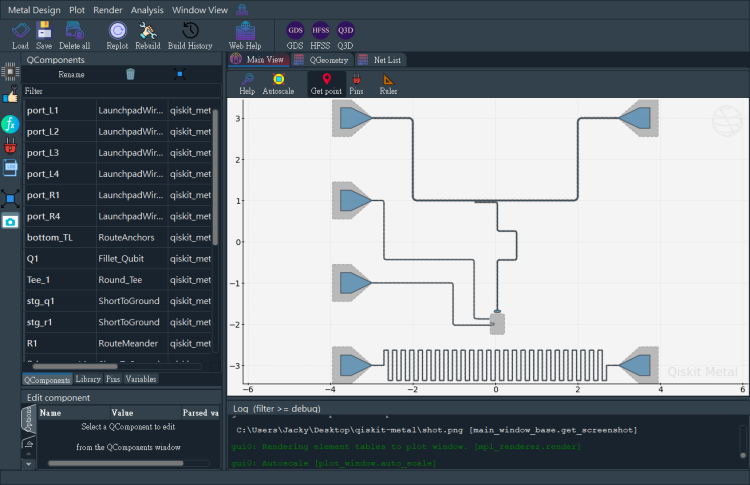

設計的總長度: 43.8mm


In [14]:
"""
Add folded transmission line between bottom ports (port_L4 and port_R4)
Total length: 49.51576mm with folded structure
"""

if draw_folded_TL:
    L = 43.8
    #delta = 5.8 + 3 - 3.0982456140350876 + 3 - 3.0017236072637754 + 3 - 3.0000302387239244 + 3 - 3.000000530503937
    delta = 5.5
    sols = find_bc_solutions(L, delta, max_n=40)
    print(sols)
    if not sols:
        print("在指定的 n 範圍內未找到可行解。")
    else:
        print(f"找到 {len(sols)} 組可行解 (n, c, b_min, b_max)：")
        for n, c, b_min, b_max in sols:
            # 取 b 為上下界中點作示範
            lower_horizontal = b_max
            upper_horizontal = lower_horizontal
            initial_horizontal = lower_horizontal
            vertical_line = c
            lower_vertical = c/2
            upper_vertical = c/2
            n_folds = n
    print(f"n={n}, vertical_line={vertical_line:.3f}, lower_horizontal={lower_horizontal:.3f}")
    # 傳輸線參數
    cpw_width = 0.01
    cpw_gap = 0.006
    folded_TL_width, folded_TL_gap = cpw_width, cpw_gap  # 與port_L4, port_R4相同的線寬
    total_length = L  # 總長度 49.51576mm

    # 計算一個完整折疊單元的長度
    one_fold_unit = upper_vertical + upper_horizontal + vertical_line + lower_horizontal + lower_vertical

    # 計算需要多少個折疊單元
    used_length = initial_horizontal  # 已使用長度
    remaining_length = total_length - used_length
    #n_folds = int(remaining_length / one_fold_unit)  # 折疊單元數量

    # 計算最後橫線長度
    final_horizontal = remaining_length - (n_folds * one_fold_unit)

    print(f"折疊單元數量: {n_folds}")
    print(f"最後橫線長度: {final_horizontal:.3f}mm")

    # 產生 folded_path (OrderedDict, value 為 tuple)
    folded_path = OrderedDict()
    start_x, start_y = port_L4.options.pos_x + 0.3, port_L4.options.pos_y  # 0.2 為起始 lead
    current_x, current_y = start_x, start_y
    folded_path[0] = (current_x, current_y)
    path_index = 1
    for i in range(n_folds):
        # 上半部垂直線
        current_y += upper_vertical
        folded_path[path_index] = (current_x, current_y)
        path_index += 1
        # 上橫線 (平的)
        current_x += upper_horizontal
        folded_path[path_index] = (current_x, current_y)
        path_index += 1
        # 垂直線
        current_y -= vertical_line
        folded_path[path_index] = (current_x, current_y)
        path_index += 1
        # 下橫線 (平的)
        current_x += lower_horizontal
        folded_path[path_index] = (current_x, current_y)
        path_index += 1
        # 下半部垂直線
        current_y += lower_vertical
        folded_path[path_index] = (current_x, current_y)
        path_index += 1

    

    # 使用 RoutePathfinder 來避免 RouteAnchors 的自動連接限制
    folded_TL = RouteAnchors(
        design, 'folded_TL',
        dict(
            pin_inputs = dict(
                start_pin = dict(component = 'port_L4', pin = 'tie'),
                end_pin = dict(component = 'port_R4', pin = 'tie')
            ),
            anchors = folded_path,
            trace_width = folded_TL_width,
            trace_gap = folded_TL_gap,
            fillet = cpw_width, 
            hfss_wire_bonds = True,
            lead = dict(start_straight=0.100, end_straight=0.100)
        )
    )
    actual_length = folded_TL.length
    print(f"元件計算後的實際長度是: {actual_length} mm")

    
gui.rebuild()
gui.autoscale()
gui.screenshot()
print(f"設計的總長度: {total_length}mm")

In [15]:
def get_xy_on_folded_path(folded_path, s):
    """
    給定folded_path (OrderedDict, key為int, value為(x, y)) 和長度s (mm)，
    回傳走s後的(x, y)座標。
    若s超過總長度，則回傳最後一點。
    """
    import numpy as np
    # 取得所有點
    points = list(folded_path.values())
    # 添加初始點
    first_point = points[0]
    zero_point = (first_point[0] -0.248, first_point[1])
    points.insert(0, zero_point)
    
    last_point = points[-1]
    extra_point = (last_point[0] + 5, last_point[1])
    points.append(extra_point)
    
    # 計算每段長度
    seg_lens = [np.hypot(points[i+1][0]-points[i][0], points[i+1][1]-points[i][1]) for i in range(len(points)-1)]
    # 扣掉轉角補償
    a = cpw_width # 轉角半徑
    seg_lens = [seg_lens[0] + (-1 + np.pi/2) * a] + [s + (-2 + np.pi/2) * a for s in seg_lens[1:]]
    
    if s == 0:
        return points[0], -1

    total = 0
    for i, seg_len in enumerate(seg_lens):
        if total + seg_len >= s:
            # 在這一段內
            remain = s - total + a
            x0, y0 = points[i]
            x1, y1 = points[i+1]
            ratio = remain / seg_len if seg_len != 0 else 0
            x = x0 + (x1 - x0) * ratio
            y = y0 + (y1 - y0) * ratio
            # 決定標記
            if i == 0:
                tag = -1
            elif i == len(seg_lens) - 1:
                tag = 5
            else:
                tag = (i - 1) % 5
            return (x, y), tag
        
        total += seg_len

In [16]:
class LShapedCPW:
    """
    通用的 L 型 CPW 走线类，支持以下六种类型：
      - initial_L: 向下 vertical，再向右剩余 horizontal
      - right_L: 向右 small (0.05)，再向下剩余 (total_length - small)
      - left_L: 向左 small (0.05)，再向下剩余
      - bottom_L: 向下 small (0.2)，再向右剩余
      - top: 向下 entire total_length（直线）
      - end_L: 向下 0.6，再向左剩余
    """
    TYPES = ("initial_L", "right_L", "left_L", "bottom_L", "top", "end_L")

    def __init__(self, design, name,
                 start_x, start_y,
                 total_length,
                 trace_width=cpw_width, trace_gap=cpw_gap, fillet=cpw_width,
                 trace_type=None,
                 folded_path=None, s=None):
        self.design = design
        self.name = name
        (self.start_x, self.start_y), self.tag = get_xy_on_folded_path(folded_path, s)
        self.total = total_length
        self.start_component = folded_TL.name
        self.trace_width = trace_width
        self.trace_gap = trace_gap
        self.fillet = fillet
        self.start_pin = "bottom"  # 默认起始 pin
        self.folded_path = folded_path
        self.s = s

        # 决定类型
        self.trace_type = trace_type or self._determine_type()
        if self.trace_type not in self.TYPES:
            raise ValueError(f"未知类型 {self.trace_type}")

        # 调用对应的 builder
        getattr(self, f"_build_{self.trace_type}")()

    def _determine_type(self):
                # tag=0: 上半部垂直線
                # tag=1: 上橫線
                # tag=2: 垂直線
                # tag=3: 下橫線
                # tag=4: 下半部垂直線
            print(f"Determining type based on tag: {self.tag}")
            if self.tag == 0:
                return "right_L"
            elif self.tag == 1:
                return "top"
            elif self.tag == 2:
                return "left_L"
            elif self.tag == 3:
                return "bottom_L"
            elif self.tag == 4:
                return "right_L"
            elif self.tag == -1:
                return "initial_L"
            elif self.tag == 5:
                return "end_L"

    def _build_initial_L(self):
        # 向下 self.vertical，再向右剩余
        down = 0.85
        #down = 1.6
        sx, sy = self.start_x, self.start_y
        if down > self.total:
            sx, sy = self.start_x, self.start_y
            short_x = sx
            short_y = sy - self.total
            self._add_short(short_x, short_y, orientation="270")
            folded_TL.add_pin(f"{self.name}_start", points = [[sx,sy],[sx,sy-0.0000001]],width = cpw_width, input_as_norm=True)
            self.start_pin = f"{self.name}_start"
            RouteStraight(design, self.name, options=dict(
                pin_inputs=dict(
                    start_pin=dict(component="folded_TL", pin=f"{self.name}_start"),
                    end_pin=dict(component=self.short_name, pin="short")
                ),
                trace_width=cpw_width, trace_gap=cpw_gap
            ))
            return

        short_x = sx + (self.total - down) + (2 - np.pi/2) * self.fillet
        short_y = sy - down
        self._add_short(short_x, short_y, orientation="0")
        folded_TL.add_pin(f"{self.name}_start", points = [[sx,sy],[sx,sy-0.0000001]],width = cpw_width, input_as_norm=True)
        self.start_pin = f"{self.name}_start"
        anchors = {
            "0": (sx, short_y)
        }
        self._add_route(anchors)


    def _build_right_L(self):
        # 先向右 small，再向下 total-small
        small = 0.05
        #small = 0.14
        sx, sy = self.start_x, self.start_y
        if small > self.total:
            sx, sy = self.start_x, self.start_y
            short_x = sx + self.total
            short_y = sy
            self._add_short(short_x, short_y, orientation="0")
            folded_TL.add_pin(f"{self.name}_start", points = [[sx,sy],[sx+0.0000001,sy]],width = cpw_width, input_as_norm=True)
            self.start_pin = f"{self.name}_start"
            RouteStraight(design, self.name, options=dict(
                pin_inputs=dict(
                    start_pin=dict(component="folded_TL", pin=f"{self.name}_start"),
                    end_pin=dict(component=self.short_name, pin="short")
                ),
                trace_width=cpw_width, trace_gap=cpw_gap
            ))
            return
        mid_x = sx + small
        mid_y = sy
        short_x = mid_x
        short_y = sy - (self.total - small + (2 - np.pi/2) * self.fillet)

        folded_TL.add_pin(f"{self.name}_start", points = [[sx,sy],[sx+0.0000001,sy]],width = cpw_width, input_as_norm=True)
        self.start_pin = f"{self.name}_start"

        # 判斷是否需要再折一次
        port4y = port_R4.options.pos_y
        ######################################################################################
        if short_y < port4y - 0.6:
            fold_x = mid_x
            fold_y = port4y - 0.6
            short_x = fold_x + (self.total - (mid_x - sx +  mid_y-fold_y) + (2 - np.pi/2) * self.fillet*2)
            short_y = fold_y
            
            # 最後 short
            self._add_short(short_x, short_y, orientation="0")
            anchors = {
                "0": (mid_x, mid_y),
                "1": (fold_x, fold_y)
            }
            self._add_route(anchors)

            
        else:
            # 原本的兩段
            self._add_short(short_x, short_y, orientation="270")
            
            anchors = {
                "0": (mid_x, mid_y),
            }
            self._add_route(anchors)

    def _build_left_L(self):
        # 向左 0.05，再向下剩余
        small = 0.05
        sx, sy = self.start_x, self.start_y
        if small > self.total:
            sx, sy = self.start_x, self.start_y
            short_x = sx - self.total
            short_y = sy
            self._add_short(short_x, short_y, orientation="180")
            folded_TL.add_pin(f"{self.name}_start", points = [[sx,sy],[sx-0.0000001,sy]],width = cpw_width, input_as_norm=True)
            self.start_pin = f"{self.name}_start"
            RouteStraight(design, self.name, options=dict(
                pin_inputs=dict(
                    start_pin=dict(component="folded_TL", pin=f"{self.name}_start"),
                    end_pin=dict(component=self.short_name, pin="short")
                ),
                trace_width=cpw_width, trace_gap=cpw_gap
            ))
            return
        mid_x = sx - small
        mid_y = sy
        short_x = mid_x
        short_y = sy - (self.total - small + (2 - np.pi/2) * self.fillet)
        folded_TL.add_pin(f"{self.name}_start", points = [[sx,sy],[sx-0.0000001,sy]],width = cpw_width, input_as_norm=True)
        self.start_pin = f"{self.name}_start"
        
        port4y = port_R4.options.pos_y
        if short_y < port4y - 0.6:
            fold_x = mid_x
            fold_y = port4y - 0.6
            short_x = fold_x + (self.total - (sx - mid_x +  mid_y-fold_y) + (2 - np.pi/2) * self.fillet*2)
            short_y = fold_y
            
            # 最後 short
            self._add_short(short_x, short_y, orientation="0")
            anchors = {
                "0": (mid_x, mid_y),
                "1": (fold_x, fold_y)
            }
            self._add_route(anchors)

        else:
            self._add_short(short_x, short_y, orientation="270")
            anchors = {
                    "0": (mid_x, mid_y)
                }
            self._add_route(anchors)


    def _build_bottom_L(self):
        # 向下 0.2，再向右剩余
        down = 0.2
        sx, sy = self.start_x, self.start_y
        mid_x = sx
        mid_y = sy - down
        short_x = sx + (self.total - down + (2 - np.pi/2) * self.fillet)
        short_y = sy - down
        self._add_short(short_x, short_y, orientation="0")
        folded_TL.add_pin(f"{self.name}_start", points = [[sx,sy],[sx,sy-0.0000001]],width = cpw_width, input_as_norm=True)
        self.start_pin = f"{self.name}_start"
        anchors = {
                "0": (mid_x, mid_y)
            }
        self._add_route(anchors)

    def _build_top(self):
        # 向下 entire total_length（直线）
        sx, sy = self.start_x, self.start_y
        short_x = sx
        short_y = sy - self.total
        self._add_short(short_x, short_y, orientation="270")
        folded_TL.add_pin(f"{self.name}_start", points = [[sx,sy],[sx,sy-0.0000001]],width = cpw_width, input_as_norm=True)
        self.start_pin = f"{self.name}_start"
        RouteStraight(design, self.name, options=dict(
            pin_inputs=dict(
                start_pin=dict(component="folded_TL", pin=f"{self.name}_start"),
                end_pin=dict(component=self.short_name, pin="short")
            ),
            trace_width=cpw_width, trace_gap=cpw_gap
        ))

    def _build_end_L(self):
        down = 0.8
        #down = 1.6
        sx, sy = self.start_x, self.start_y
        if down > self.total:
            sx, sy = self.start_x, self.start_y
            short_x = sx
            short_y = sy - self.total
            self._add_short(short_x, short_y, orientation="270")
            folded_TL.add_pin(f"{self.name}_start", points = [[sx,sy],[sx,sy-0.0000001]],width = cpw_width, input_as_norm=True)
            self.start_pin = f"{self.name}_start"
            RouteStraight(design, self.name, options=dict(
                pin_inputs=dict(
                    start_pin=dict(component="folded_TL", pin=f"{self.name}_start"),
                    end_pin=dict(component=self.short_name, pin="short")
                ),
                trace_width=cpw_width, trace_gap=cpw_gap
            ))
            return
        mid_x = sx
        mid_y = sy - down
        short_x = mid_x - (self.total - down + (2 - np.pi/2) * self.fillet)
        short_y = mid_y
        self._add_short(short_x, short_y, orientation="180")
        folded_TL.add_pin(f"{self.name}_start", points = [[sx,sy],[sx,sy-0.0000001]],width = cpw_width, input_as_norm=True)
        self.start_component = 'folded_TL'
        self.start_pin = f"{self.name}_start"
        anchors = {
            "0": (mid_x, mid_y)
        }
        self._add_route(anchors, leading=0.200)


    def _add_short(self, x, y, orientation):
        stg_name = f"{self.name}_stg"
        ShortToGround(self.design, stg_name,
                      options=dict(
                          pos_x=x,
                          pos_y=y,
                          orientation=orientation
                      ))
        self.short_name = stg_name

    def _add_route(self, anchors, leading=0.050):
        RouteAnchors(self.design, self.name,
            options=dict(
                pin_inputs=dict(
                    start_pin=dict(component=self.start_component, pin=self.start_pin),
                    end_pin=dict(component=self.short_name, pin="short")
                ),
                trace_width=self.trace_width,
                trace_gap=self.trace_gap,
                fillet=self.fillet,
                anchors=anchors,
                lead = dict(start_straight=leading)
            )
        )


s_list: [0.0, 7.97377, 17.12436, 26.480999999999998, 35.631589999999996, 43.60536]
Determining type based on tag: -1
Determining type based on tag: 2
Determining type based on tag: 0
Determining type based on tag: 4
Determining type based on tag: 2
Determining type based on tag: 5


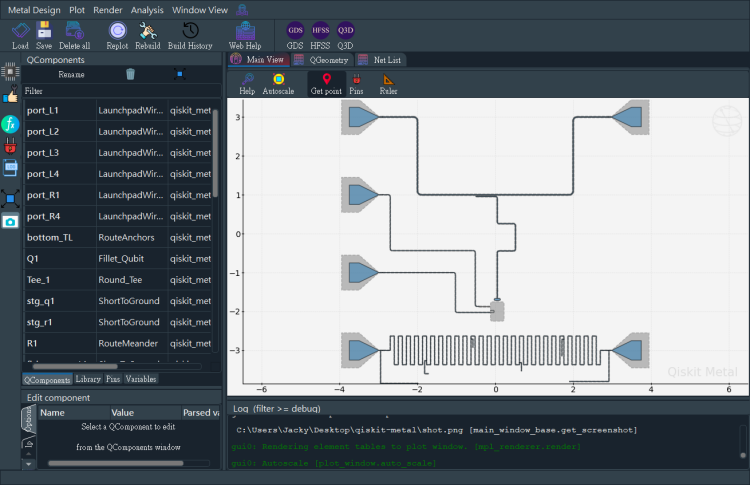

In [17]:
# 參數設定
#s_pre = [0.0, 7.97377, 9.15059, 9.35664, 9.15059, 7.97377]
#s_pre = [0.0, 8.59091, 9.51299, 9.61708, 9.51299, 8.59091]
#s_pre = [0.0, 7.33072, 8.67702, 9.01229, 8.67702, 7.33072]
#s_pre = [0.0, 7.97125, 9.14771, 9.35369, 9.14771, 7.97125]
#s_pre = [0.0, 8.95833, 10.362, 10.6312, 10.362, 8.95833]
#s_pre = [0.0, 8.12347, 9.15059, 9.35664, 9.15059, 7.97377]
#s_pre = [0.0, 10600.2, 12410.7, 12809.3, 12410.7, 10600.2]
#s_pre = [0.0, 7842.05, 8999.45, 9202.1, 8999.45, 7842.05]
#s_pre = [0.0, 8386.57, 9215.64, 8386.57]
#s_pre = [0.0, 7783.55, 9050.3, 9351.59, 9351.59, 9050.3, 7783.55]
#s_pre = [0.0, 7973.77, 9150.59, 9356.64, 9150.59, 7973.77]
#s_pre = [0.0, 7973.77, 8000, 8700, 7973.77]
s_pre = [0.0, 7973.77, 9150.59, 9356.64, 9150.59, 7973.77]
s_pre = [x / 1000 for x in s_pre]

s_list = [sum(s_pre[:i+1]) for i in range(len(s_pre))]
print("s_list:", s_list)

#s_list =[0.1, 0.65, 19.48473, 31, 40.45, 49.71576]
#length_p = [1.81047, 0.477466, 0.262704, 0.262704, 0.477466, 1.81047]  # 每段的长度
#length_p = [1.18509, 0.236079, 0.130899, 0.130899, 0.236079, 1.18509] 
#length_p = [2.56819, 0.817071, 0.441439, 0.441439, 0.817071, 2.56819] 
#length_p = [1.8099, 0.477316, 0.262621, 0.262621, 0.477316, 1.8099] 
#length_p = [2.26791, 0.629384, 0.34518, 0.34518, 0.629384, 2.26791] 
#length_p = [1.81047, 0.477466, 0.262704, 0.262704, 0.477466, 1.81047]
#length_p = [1780.57, 469.58, 258.365, 258.365, 469.58, 1780.57]
#length_p = [1342.21, 335.114, 335.114, 1342.21]
#length_p = [2034.73, 561.117, 286.154, 244.474, 286.154, 561.117, 2034.73]
#length_p = [1810.47, 477.466, 262.704, 262.704, 477.466, 1810.47]
#length_p = [1810.47, 477.466, 262.704, 477.466, 1810.47]
length_p = [1810.47, 477.466, 262.704, 262.704, 477.466, 1810.47]
length_p = [x / 1000 for x in length_p]
if draw_folded_TL:
    for idx, s_val in enumerate(s_list):
        #if idx==3: continue
        LShapedCPW(design, f"cpw_p{idx}",
            start_x, start_y,
            total_length=length_p[idx],folded_path=folded_path, s=s_val)

gui.rebuild()
gui.autoscale()
gui.screenshot()


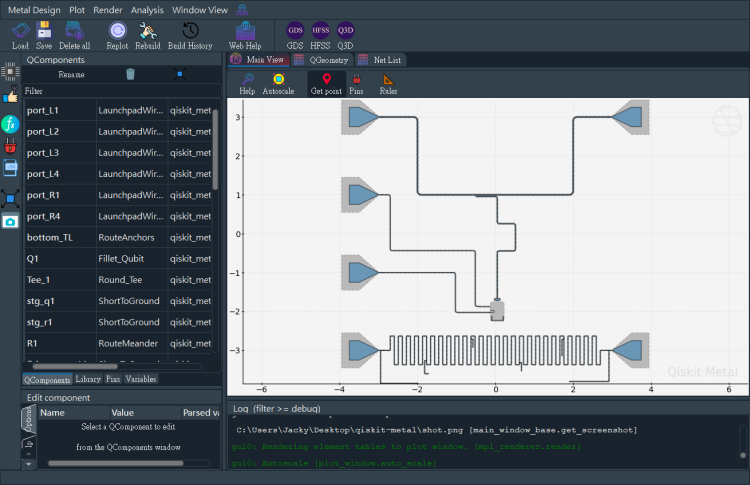

In [18]:
class UShapeComponent:
    """
    U形元件類別
    
    參數說明:
    - cx, cy: 中心點座標
    - bl: 底部寬度 (預設 0.3)
    - sh: 側邊高度 (預設 0.1)  
    - tw: 線條厚度 (預設 0.01)
    """
    
    def __init__(self, design, base_name='u_shape', bl=0.3, sh=0.1, tw=0.01):
        """
        初始化 U 形元件
        
        Args:
            design: 設計物件
            base_name: 元件基礎名稱
            bl: 底部寬度
            sh: 側邊高度
            tw: 線條厚度
        """
        self.design = design
        self.base_name = base_name
        self.bl = bl  # 底部寬度
        self.sh = sh  # 側邊高度
        self.tw = tw  # 線條厚度
        
        # 儲存矩形元件的參考
        self.rect_bottom = None
        self.rect_left = None
        self.rect_right = None
    
    def create(self, cx, cy):
        """
        在指定位置創建 U 形元件
        
        Args:
            cx: 中心點 X 座標
            cy: 中心點 Y 座標
        """
        # === 計算各部分位置與尺寸 ===
        
        # 底部矩形
        self.rect_bottom = Rectangle(
            self.design, 
            f'{self.base_name}_bottom', 
            options=dict(
                pos_x=cx,
                pos_y=cy,
                width=self.bl,
                height=self.tw
            )
        )
        
        # 左側矩形
        left_x = cx - self.bl / 2 + self.tw / 2
        left_y = cy + self.sh / 2 - self.tw / 2
        self.rect_left = Rectangle(
            self.design,
            f'{self.base_name}_left',
            options=dict(
                pos_x=left_x,
                pos_y=left_y,
                width=self.tw,
                height=self.sh
            )
        )
        
        # 右側矩形
        right_x = cx + self.bl / 2 - self.tw / 2
        right_y = cy + self.sh / 2 - self.tw / 2
        self.rect_right = Rectangle(
            self.design,
            f'{self.base_name}_right',
            options=dict(
                pos_x=right_x,
                pos_y=right_y,
                width=self.tw,
                height=self.sh
            )
        )

        self.rect_bottom.add_pin(f"node", points = [[cx,cy],[cx,cy-0.0000001]],width = cpw_width, input_as_norm=True)
        
        
        return self
    
    def update_position(self, cx, cy):
        """
        更新 U 形元件位置
        
        Args:
            cx: 新的中心點 X 座標
            cy: 新的中心點 Y 座標
        """
        if not self.rect_bottom:
            raise ValueError("請先使用 create() 方法創建元件")
        
        # 更新底部矩形
        self.rect_bottom.options['pos_x'] = cx
        self.rect_bottom.options['pos_y'] = cy
        
        # 更新左側矩形
        left_x = cx - self.bl / 2 + self.tw / 2
        left_y = cy + self.sh / 2 - self.tw / 2
        self.rect_left.options['pos_x'] = left_x
        self.rect_left.options['pos_y'] = left_y
        
        # 更新右側矩形
        right_x = cx + self.bl / 2 - self.tw / 2
        right_y = cy + self.sh / 2 - self.tw / 2
        self.rect_right.options['pos_x'] = right_x
        self.rect_right.options['pos_y'] = right_y
    
    def update_dimensions(self, bl=None, sh=None, tw=None):
        """
        更新 U 形元件尺寸
        
        Args:
            bl: 底部寬度 (可選)
            sh: 側邊高度 (可選)
            tw: 線條厚度 (可選)
        """
        if not self.rect_bottom:
            raise ValueError("請先使用 create() 方法創建元件")
        
        # 更新參數
        if bl is not None:
            self.bl = bl
        if sh is not None:
            self.sh = sh
        if tw is not None:
            self.tw = tw
        
        # 獲取當前中心位置
        cx = self.rect_bottom.options['pos_x']
        cy = self.rect_bottom.options['pos_y']
        
        # 重新計算位置和尺寸
        self.update_position(cx, cy)
        
        # 更新尺寸
        self.rect_bottom.options['width'] = self.bl
        self.rect_bottom.options['height'] = self.tw
        
        self.rect_left.options['width'] = self.tw
        self.rect_left.options['height'] = self.sh
        
        self.rect_right.options['width'] = self.tw
        self.rect_right.options['height'] = self.sh
    
    def get_components(self):
        """
        取得所有矩形元件
        
        Returns:
            tuple: (底部矩形, 左側矩形, 右側矩形)
        """
        return (self.rect_bottom, self.rect_left, self.rect_right)
    
    def delete(self):
        """
        刪除 U 形元件的所有矩形
        """
        components = [self.rect_bottom, self.rect_left, self.rect_right]
        for component in components:
            if component:
                try:
                    component.delete()
                except:
                    pass
        
        self.rect_bottom = None
        self.rect_left = None
        self.rect_right = None


# === 使用範例 ===
def example_usage():
    """
    使用範例
    """
    # 創建 U 形元件
    u_shape = UShapeComponent(design, 'my_u_shape')
    
    # 在指定位置創建
    cx, cy = 0, 0  # 輸入你的座標
    u_shape.create(cx, cy)
    
    # 重建和顯示
    gui.rebuild()
    gui.autoscale()
    gui.screenshot()
    
    # 可選：更新位置
    # u_shape.update_position(1, 1)
    
    # 可選：更新尺寸
    # u_shape.update_dimensions(bl=0.5, sh=0.2, tw=0.01)
    
    return u_shape


# === 快速創建函數 ===
def create_u_shape(design, cx, cy, name='u_shape', bl=0.3, sh=0.1, tw=0.01):
    """
    快速創建 U 形元件的便利函數
    
    Args:
        design: 設計物件
        cx, cy: 中心座標
        name: 元件名稱
        bl: 底部寬度
        sh: 側邊高度  
        tw: 線條厚度
    
    Returns:
        UShapeComponent: U 形元件實例
    """
    u_shape = UShapeComponent(design, name, bl, sh, tw)
    u_shape.create(cx, cy)
    return u_shape


qubit_couple_gap = 0.06
if draw_coupling_pad_1:
    padbottom_x = Q1.options.pos_x
    padbottom_y = Q1.options.pos_y - Q1.options.pad_gap/2 - Q1.options.pad_height -Q1.options.arm_length - 0.005 - qubit_couple_gap
    coupling_pad1 = create_u_shape(design, cx=padbottom_x, cy=padbottom_y, name='coupling_pad1')   

if draw_coupling_pad_2:
    padbottom_x = Q3.options.pos_x
    padbottom_y = Q3.options.pos_y - Q3.options.pad_gap/2 - Q3.options.pad_height -Q3.options.arm_length - 0.005 - qubit_couple_gap
    coupling_pad3 = create_u_shape(design, cx=padbottom_x, cy=padbottom_y, name='coupling_pad3')  

gui.rebuild()
gui.autoscale()
gui.screenshot()

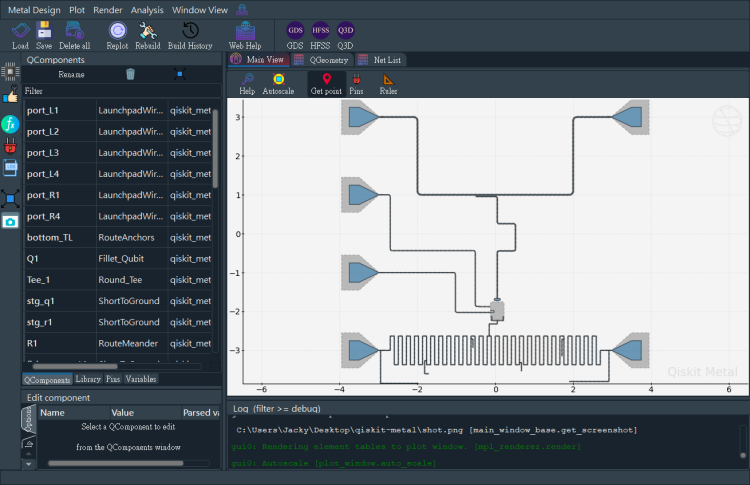

In [19]:
for i in range(n_folds):
    if i+1 != 13 and i+1 !=20:
        continue
    idx_start = 1 + i*5
    idx_end = 2 + i*5
    if idx_end >= len(folded_path):
        break
    x0, y0 = folded_path[idx_start]
    x1, y1 = folded_path[idx_end]
    xm = (x0 + x1) / 2
    ym = (y0 + y1) / 2
    # 放 VirtualJunction
    folded_TL.add_pin(f"couple_point{i+1}", points = [[xm,ym],[xm,ym+0.0000001]],width = cpw_width, input_as_norm=True)
    

if draw_couple_line_1:
    RoutePathfinder(
        design, 'cpw_couple1',
        dict(
            trace_width=cpw_width,
            trace_gap=cpw_gap,
            fillet=0.01,
            hfss_wire_bonds=True,
            lead=dict(start_straight=0.1, end_straight=0.1),
            pin_inputs=dict(
                start_pin=dict(component='folded_TL', pin='couple_point13'),
                end_pin=dict(component='coupling_pad1_bottom', pin='node')
            )
        )
    )

if draw_couple_line_2:
    RoutePathfinder(
        design, 'cpw_couple2',
        dict(
            trace_width=cpw_width,
            trace_gap=cpw_gap,
            fillet=0.01,
            hfss_wire_bonds=True,
            lead=dict(start_straight=0.1, end_straight=0.1),
            pin_inputs=dict(
                start_pin=dict(component='folded_TL', pin='couple_point20'),
                end_pin=dict(component='coupling_pad3_bottom', pin='node')
            )
        )
    )

gui.rebuild()
gui.autoscale()
gui.screenshot()

In [20]:
# grd_gap = 0.010

# RA_len = 4.5
# l_couple = 0.2
# otg_qA = OpenToGround(design, 'otg_qA',
#     {'pos_x': -1.6, 'pos_y': 1.0, 'orientation': '  0', 'width': res_width, 'gap': res_gap, 'termination_gap': res_gap})
# stg_rA = ShortToGround(design, 'stg_rA',
#     {'pos_x': -1.6-l_couple, 'pos_y': port_L1.options.pos_y-TL_gap-res_gap-(TL_width+res_width)/2-grd_gap, 'orientation': '180'})
# RA = RouteMeander(design, 'RA', 
#     options = dict(total_length = RA_len, fillet=1.5*(res_width+res_gap*2), hfss_wire_bonds = True, 
#                    lead = dict(start_straight=l_couple, end_straight=0.100), 
#                    trace_width = res_width, trace_gap = res_gap,
#                    meander = dict(
#                        spacing = abs(otg_qA.options.pos_y-stg_rA.options.pos_y)/6, 
#                        asymmetry=-1*l_couple
#                    ),# 
#                    pin_inputs = Dict(start_pin = Dict(component = 'stg_rA', pin = 'short'),
#                                        end_pin = Dict(component = 'otg_qA', pin = 'open'))))
# RB_len = 4.45
# l_couple = 0.2
# otg_qB = OpenToGround(design, 'otg_qB',
#     {'pos_x':  1.6, 'pos_y': 1.0, 'orientation': '180', 'width': res_width, 'gap': res_gap, 'termination_gap': res_gap})
# stg_rB = ShortToGround(design, 'stg_rB',
#     {'pos_x':  1.6+l_couple, 'pos_y': port_L1.options.pos_y-TL_gap-res_gap-(TL_width+res_width)/2-grd_gap, 'orientation': '  0'})
# RB = RouteMeander(design, 'RB', 
#     options = dict(total_length = RB_len, fillet=1.5*(res_width+res_gap*2), hfss_wire_bonds = True, 
#                    lead = dict(start_straight=l_couple, end_straight=0.150), 
#                    trace_width = res_width, trace_gap = res_gap,
#                    meander = dict(
#                        spacing = abs(otg_qB.options.pos_y-stg_rB.options.pos_y)/6, 
#                        asymmetry=+1*l_couple
#                    ),# 
#                    pin_inputs = Dict(start_pin = Dict(component = 'stg_rB', pin = 'short'),
#                                        end_pin = Dict(component = 'otg_qB', pin = 'open'))))

#JJ_test_pocket_L = Rectangle(design, 'JJ_test_pocket_L', 
#    dict(pos_x =-2.0, pos_y =-2.0, width = 0.5, height = 1.0, subtract=True))
#JJ_test_pocket_R = Rectangle(design, 'JJ_test_pocket_R', 
#    dict(pos_x = 1.5, pos_y =-2.0, width = 0.5, height = 1.0, subtract=True))
# pad_t_1 = Rectangle(design, 'pad_t_1', 
#     dict(pos_x =-1.0, pos_y =-1.3, width = 0.15, height = 0.15, subtract=0))
# pad_b_1 = Rectangle(design, 'pad_b_1', 
#     dict(pos_x =-1.0, pos_y =-1.1, width = 0.15, height = 0.15, subtract=0))

#gui.rebuild()
#gui.autoscale()
#gui.screenshot()

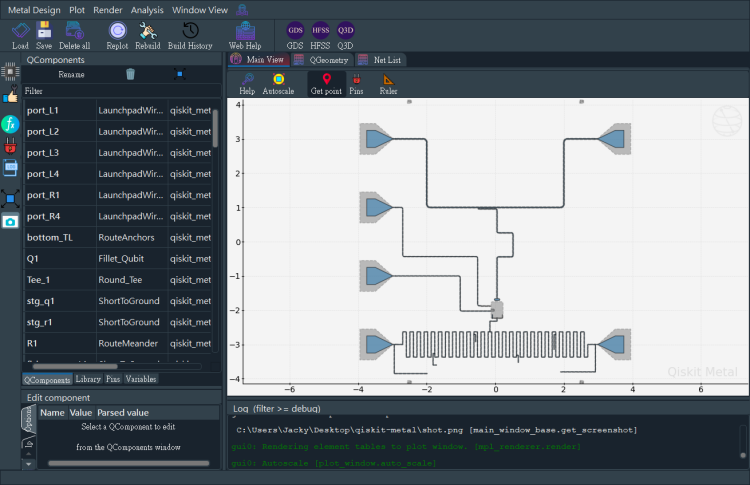

In [21]:
x_mark, y_mark = 2.5, 4.1
x_0 , y_0 = x_mark-0.05, y_mark-0.05
x_cross, y_cross = x_mark-0.05+0.07925, y_mark+0.0025
mark_pocket_1 = Rectangle(design, 'mark_pocket_1',
    dict(pos_x= x_mark+0.01, pos_y= y_mark, width=0.120, height=0.100, subtract=True))
mark_cross_1 = Cross(design, 'mark_cross_1', 
    dict(pos_x= x_cross, pos_y= y_cross, layer='2', width=0.040, height=0.040, trace_width=0.005, subtract=True))
mark_L_v = Rectangle(design, 'mark_L_v',
    dict(pos_x= x_cross + 0.0125, pos_y= y_cross + 0.0175, layer='2', width=0.005, height=0.005, subtract=True))
mark_L_h = Rectangle(design, 'mark_L_h',
    dict(pos_x= x_cross + 0.015, pos_y= y_cross + 0.0125, layer='2', width=0.01, height=0.005, subtract=True))
mark_cross_1_b = Cross(design, 'mark_cross_1_b', 
    dict(pos_x= x_0+0.02675, pos_y= y_0+0.0275, layer='2', width=0.020, height=0.020, trace_width=0.003, subtract=True))
mark_cross_1_t = Cross(design, 'mark_cross_1_t', 
    dict(pos_x= x_0+0.02675, pos_y= y_0+0.0275+0.045, layer='2', width=0.020, height=0.020, trace_width=0.003, subtract=True))
mark_b_rec1 = Rectangle(design, 'mark_b_rec1',
    dict(pos_x= x_0+0.01775, pos_y= y_0+0.0365, layer='2', width=0.005, height=0.005, subtract=True))
mark_b_rec2 = Rectangle(design, 'mark_b_rec2',
    dict(pos_x= x_0+0.01775+0.018, pos_y= y_0+0.0365, layer='2', width=0.005, height=0.005, subtract=True))
mark_b_rec3 = Rectangle(design, 'mark_b_rec3',
    dict(pos_x= x_0+0.01775+0.018, pos_y= y_0+0.0365-0.018, layer='2', width=0.005, height=0.005, subtract=True))
mark_t_tri = RightTriangle(design, 'mark_t_tri',dict(pos_x= x_0 +0.03325+0.0025, pos_y= y_0+0.079+0.0025, layer='2', width=0.005, height=0.005, subtract=True))

mark_group_1 = [
    mark_pocket_1,
    mark_cross_1,
    mark_L_v,
    mark_L_h,
    mark_cross_1_b,
    mark_cross_1_t,
    mark_b_rec1,
    mark_b_rec2,
    mark_b_rec3,
    mark_t_tri
]
mark_group_2_names = [
    'mark_pocket_2',
    'mark_cross_2',
    'mark_L_v_2',
    'mark_L_h_2',
    'mark_cross_2_b',
    'mark_cross_2_t',
    'mark_b_rec1_2',
    'mark_b_rec2_2',
    'mark_b_rec3_2',
    'mark_t_tri_2'
]

mark_2 = design.copy_multiple_qcomponents(
    mark_group_1,
    mark_group_2_names,
    [dict(pos_x=-c.options.pos_x, pos_y=c.options.pos_y) for c in mark_group_1]
)

mark_group_3_names = [n.replace('_2', '_3') for n in mark_group_2_names]

mark_3 = design.copy_multiple_qcomponents(
    mark_group_1,
    mark_group_3_names,
    [dict(pos_x=-c.options.pos_x, pos_y=-c.options.pos_y) for c in mark_group_1]
)

mark_group_4_names = [n.replace('_2', '_4') for n in mark_group_2_names]

mark_4 = design.copy_multiple_qcomponents(
    mark_group_1,
    mark_group_4_names,
    [dict(pos_x=c.options.pos_x, pos_y=-c.options.pos_y) for c in mark_group_1]
)

mark_2['mark_t_tri_2'].options.orientation = 90
mark_3['mark_t_tri_3'].options.orientation = 180
mark_4['mark_t_tri_4'].options.orientation = 270

gui.rebuild()
gui.autoscale()
gui.screenshot()

In [22]:
design.components.keys()

['port_L1',
 'port_L2',
 'port_L3',
 'port_L4',
 'port_R1',
 'port_R4',
 'bottom_TL',
 'Q1',
 'Tee_1',
 'stg_q1',
 'stg_r1',
 'R1',
 'fl_loop_stg_1A',
 'fl_loop_stg_1B',
 'fl_loop_route_1',
 'fl_q_stg_1',
 'fl_q_route_1',
 'cl_q1_gap_1',
 'cl_q1_trace_1',
 'cl_q_stg_1',
 'cl_q_route_1',
 'folded_TL',
 'cpw_p0_stg',
 'cpw_p0',
 'cpw_p1_stg',
 'cpw_p1',
 'cpw_p2_stg',
 'cpw_p2',
 'cpw_p3_stg',
 'cpw_p3',
 'cpw_p4_stg',
 'cpw_p4',
 'cpw_p5_stg',
 'cpw_p5',
 'coupling_pad1_bottom',
 'coupling_pad1_left',
 'coupling_pad1_right',
 'cpw_couple1',
 'mark_pocket_1',
 'mark_cross_1',
 'mark_L_v',
 'mark_L_h',
 'mark_cross_1_b',
 'mark_cross_1_t',
 'mark_b_rec1',
 'mark_b_rec2',
 'mark_b_rec3',
 'mark_t_tri',
 'mark_pocket_2',
 'mark_cross_2',
 'mark_L_v_2',
 'mark_L_h_2',
 'mark_cross_2_b',
 'mark_cross_2_t',
 'mark_b_rec1_2',
 'mark_b_rec2_2',
 'mark_b_rec3_2',
 'mark_t_tri_2',
 'mark_pocket_3',
 'mark_cross_3',
 'mark_L_v_3',
 'mark_L_h_3',
 'mark_cross_3_b',
 'mark_cross_3_t',
 'mark_b_rec1_3

# To GDS

In [23]:
gds_render = design.renderers.gds
gds_render.options

{'short_segments_to_not_fillet': 'True',
 'check_short_segments_by_scaling_fillet': '2.0',
 'gds_unit': 0.001,
 'ground_plane': 'True',
 'negative_mask': {'main': []},
 'fabricate': 'False',
 'corners': 'circular bend',
 'tolerance': '0.00001',
 'precision': '0.000000001',
 'width_LineString': '10um',
 'path_filename': '../resources/Fake_Junctions.GDS',
 'junction_pad_overlap': '5um',
 'max_points': '199',
 'cheese': {'datatype': '100',
  'shape': '0',
  'cheese_0_x': '25um',
  'cheese_0_y': '25um',
  'cheese_1_radius': '100um',
  'view_in_file': {'main': {1: True}},
  'delta_x': '100um',
  'delta_y': '100um',
  'edge_nocheese': '200um'},
 'no_cheese': {'datatype': '99',
  'buffer': '25um',
  'cap_style': '2',
  'join_style': '2',
  'view_in_file': {'main': {1: True}}},
 'bounding_box_scale_x': '1.2',
 'bounding_box_scale_y': '1.2'}

In [24]:
# gds_render.options.update(dict(path_filename='fluxonium_JJ_sample_wide_loop.gds', junction_pad_overlap='0um'))

In [25]:
gds_render.options.fabricate = True
gds_render.options.negative_mask = dict(main=[2])
gds_render.options.no_cheese['view_in_file']['main']={1: False, 2: False}
gds_render.options.no_cheese['buffer']='20um'
gds_render.options.cheese['edge_nocheese']='0.9mm'
#gds_render.options.cheese['edge_nocheese']='4.9mm'
gds_render.options.cheese['view_in_file']['main']={1: True, 2:False}
gds_render.options.cheese.update(dict(cheese_0_x=0.005, cheese_0_y=0.005, delta_x=0.05, delta_y=0.05))

In [26]:
design.qgeometry.tables['junction']

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance


In [27]:

design.renderers.gds.options['precision'] = '1e-9'
design.renderers.gds.options['tolerance'] = '1e-7'
design.renderers.gds.options['max_points'] = '10000000'
#design.renderers.gds.options['corners'] = 'circular bend'
#design.renderers.gds.options['chord_error'] = '1um'

design.renderers.gds.export_to_gds(save_file_name)

06:46AM 56s WARNING [_qgeometry_to_gds]: Unexpected shapely object geometry.The variable qgeometry_element is <class 'numpy.float64'>, method can currently handle Polygon and FlexPath.
06:46AM 56s WARNING [_import_junction_gds_file]: Not able to find file:"../resources/Fake_Junctions.GDS".  Not used to replace junction. Checked directory:"c:\Users\Jacky\Desktop\resources".
  cell.to_gds(outfile, self.unit / self.precision, timestamp=timestamp)

  self.lib.write_gds(file_name)



1